<div style="border: ridge lightblue 2px; padding: 20px">
    
# Исследование закономерностей продаж компьютерных игр интернет-магазина "Стримчик".

*Суть проекта:* мы работаем в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, _Xbox_ или _PlayStation_). Нам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

В нашем распоряжении данные до 2016 года. Представим, что сейчас декабрь 2016 г., и мы планируем кампанию на 2017-й. Нужно отработать принцип работы с данными.

В наборе данных попадается аббревиатура _ESRB (Entertainment Software Rating Board)_ — это ассоциация, определяющая возрастной рейтинг компьютерных игр. _ESRB_ оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

**Описание данных**

- `Name` — название игры
- `Platform` — платформа
- `Year_of_Release` — год выпуска
- `Genre` — жанр игры
- `NA_sales` —_ продажи в Северной Америке (миллионы проданных копий)
- `EU_sales` — продажи в Европе (миллионы проданных копий)
- `JP_sales` — продажи в Японии (миллионы проданных копий)
- `Other_sales` —_ продажи в других странах (миллионы проданных копий)
- `Critic_Score` — оценка критиков (максимум 100)
- `User_Score` — оценка пользователей (максимум 10)
- `Rating` — рейтинг от организации `ESRB` (англ. `Entertainment Software Rating Board)`. Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

Данные за 2016 год могут быть неполными.

---
    
**Ход исследования**
    
Данные получим из файла: games.csv. О качестве датасета информации нет. Перед тем как приступать к цели исследования, нам необходимо изучить данные.
    
Проверим данные на предмет ошибок и оценим их влияние на результаты исследования. В процессе преодобработки данных попробуем исправить все ошибки, которые могут привести к искажению конечного результата. Далее мы проведем исследовательский анализ данных, составим портрет пользователя для каждого региона, проверим гипотезы и напишем общий вывод.
    
Таким образом, мое исследование пройдет в следующие этапы:
    
- Загрузка и предобработка данных.
- Подготовка данных к исследованию.
- Исследовательский анализ данных.
- Составление портретов пользователей игр для каждого региона.
- Проверка гипотез.
- Написание общих выводов.

# Шаг 1. Загрузка данных и изучение общей информации

### 1.1. Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним его в датафрейм.

Импортируем необходимые нам библиотеки для работы с данными:

In [9]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as st

Сохраним файл с данными в датафрейм:

In [11]:
try:
    games = pd.read_csv('/datasets/games.csv')
except:
    games = pd.read_csv('C:/Users/etols/Downloads/games.csv')

Напишем функцию для проведения первичной предобработки данных для нашего датасета:

In [13]:
def review(data):
    print(data.info())
    print('--------------------')
    display(data.head())
    print('--------------------')
    display(data.describe())
    print('--------------------')
    print('Пропусков в данных:')
    print(data.isna().sum())
    print('--------------------')
    print('Дубликатов в данных:', data.duplicated().sum())

In [15]:
review(games)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
--------------------


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


--------------------


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


--------------------
Пропусков в данных:
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64
--------------------
Дубликатов в данных: 0


***ВЫВОДЫ:***

- мы импортировали необходимые библиотеки для работы с данными
- написали функцию для проведения первичной предобработки данных
- при выводе описательной статистики мы увидели, что в столбце `Year_of_Release`, минимальное значение составляет 1980 год - далее проверим, может ли такое быть, и что за данные содержатся в этой строке
- мы выяснили, что явных дубликатов в данных нет
- посмотрели пропуски в данных, они есть в следующих столбцах: `Name` и `Genre` (2 пропуска), `Year_of_Release` (269 пропусков) и очень много пропусков в столбцах `Critic_Score` (8578), `User_Score` (6701) и `Rating` (6766).

# Шаг 2. Подготовка данных

### 2.1. Заменим названия столбцов (приведем к нижнему регистру)

In [20]:
# games.columns = [x.lower() for x in games.columns.values]
# games.sample()

In [21]:
games.columns = games.columns.str.lower()
games.sample()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
7087,.hack//G.U. Vol.2//Reminisce,PS2,2006.0,Role-Playing,0.11,0.09,0.0,0.03,NaN,NaN,NaN


### 2.2. Заполнение пропусков

Посмотрим еще раз на столбцы с пропусками, визуализируем процент пропущенных значений от общего количества данных.

In [27]:
games.isna().sum().sort_values(ascending=False)

critic_score       8578
rating             6766
user_score         6701
year_of_release     269
name                  2
genre                 2
platform              0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

In [28]:
round(games.isna().mean()* 100, 2).sort_values(ascending=False)

critic_score       51.32
rating             40.48
user_score         40.09
year_of_release     1.61
name                0.01
genre               0.01
platform            0.00
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
dtype: float64

In [32]:
def pass_value_barh(dfg):
    try:
        (
            (dfg.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh',
                  figsize = (10,4),
                  rot = -5,
                  legend = False,
                  fontsize = 9,
                  alpha=.8)
         );    
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')

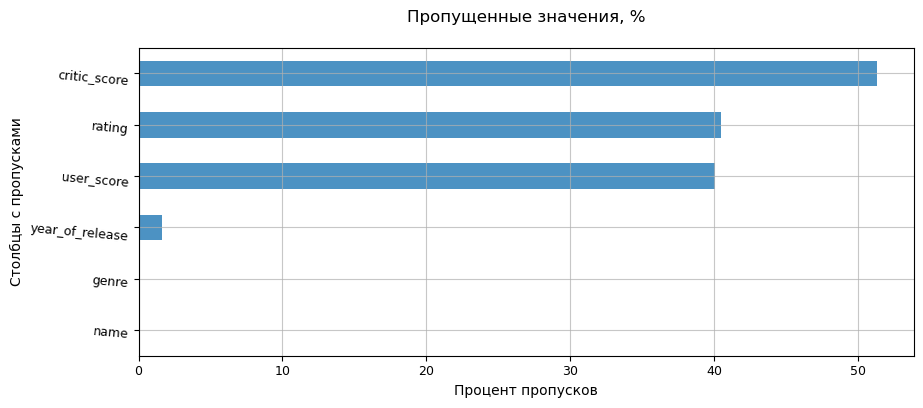

In [33]:
pass_value_barh(games)
plt.title('Пропущенные значения, %' + "\n", fontsize=12)
plt.xlabel('Процент пропусков', fontsize=10)
plt.ylabel('Столбцы с пропусками', fontsize=10)

plt.grid(alpha=.7)
plt.show()

Начнем с пропусков в столбцах `name` и `genre`, их всего 2, считаю, что вполне такое малое количество мы можем удалить без ущерба для нашего исслудования:

In [35]:
games[games['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Видим, что эти строки с 2 пропусками в имени и жанре одинаковые, удалим эти строки.

In [37]:
games = games.dropna(subset=['name'])

Далее посмотрим на пропуски в столбце `year_of_release`:

In [39]:
'{:.1%}'.format(games['year_of_release'].isna().sum() / games['year_of_release'].shape[0])

'1.6%'

Пропусков в столбце с годом всего 1,6 % от общего количества - по стандарту если пропусков менее 5% от общего количества данных, чаще всего мы можем от них избавиться, что и сделаем:

In [41]:
games = games.dropna(subset=['year_of_release'])

Посмотрим, как обстоит дело со столбцами, в которых почти половина пропущенных значений от общего количества всего датасета, например, столбец `critic_score`:

In [43]:
games['critic_score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 41., 36., 31., 27., 35., 26., 19., 28., 23.,
       24., 21., 17., 13.])

Заполнять пропуски каким-то усредненным или медианным значением нецелесообразно, попробуем использовать заглушку. Попробуем взять числовую заглушку, например, `0`, данного значения нет, поэтому легко сможем их потом отфильтровать.

In [45]:
games['critic_score'] = games['critic_score'].fillna(0)

Обратимся к столбцу `user_score`, тоже почти половина пропусков от общего количества, и также, как и в случае предыдущего столбца, желательно поменять на числовую заглушку, поскольку впоследствии нам точно нужно будет в этом столбце изменить тип данных. Посмотрим ан уникальные значения:

In [47]:
games['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

Нулевое значение уже присутствует в данных, поэтому заполнить нулем не получится. Возьмем отрицательное, чтобы мы могли позднее по этому значению отфильтровать пропуски.

In [49]:
games['user_score'] = games['user_score'].fillna(-1)

Значение «tbd» в столбце `user_score` означает, что оценка пользователей ещё не определена. Аббревиатура «tbd» расшифровывается как «to be determined» (с английского — «будет определён позднее»). В принципе данное значение также можно заменить на заглушку, что мы и сделаем.

In [51]:
games.loc[games['user_score'] == 'tbd', 'user_score'] = '-1'

Теперь посмотрим на столбец `rating`:

In [53]:
games['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

Целых 9949 пропусков, удалять естественно не будем, заменим на заглушку, например, "не указан":

In [55]:
games['rating'] = games['rating'].fillna('не указан')

Проверим еще раз на наличие пропусков:

In [57]:
games.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

***Мы обработали пропуски во всех столбцах, использовали различные способы обработки пропущенных значений: удаление пропущенных значений, замена различного рода заглушками.***

Пропуски могли появиться по разным причинам, например: 
- игра не получила рецензий от критиков (например, если это какая-то инди-игра, либо малоизвестны проект)
- данные о пользовательских оценках не собирались (например, если игра слишком старая)
- игра не проходила официальный рейтинговый контроль (например, ESRB)
- ошибка при внесении данных (касается пропусков в столбцах `name` и `genre`)

### 2.3. Преобразуем данные в нужные типы. Опишем, в каких столбцах заменили тип данных и почему

Менять тип данных мы будем в следующих столбцах: `year_of_release` (с типа данных float64 в целочисленный тип данных integer, так как год может быть только целым числом) и `user_score` (с типа данных object в тип float64, так как пользовательские оценки отображены числами с плавающей точкой, а не строка).

In [62]:
games['year_of_release'] = games['year_of_release'].astype('int64')
games['user_score'] = games['user_score'].astype('float64')

In [63]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  float64
 9   user_score       16444 non-null  float64
 10  rating           16444 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


В принципе, можно было бы изменить тип данных в столбце `critic_score`, поскольку, как мы посмотрели ранее, в данном столбце представлены только целочисленные значения, но это необязательно, плюс если мы впоследствии будем строить зависимости между этими двумя столбцами, то пусть тип данных в них остается одинаковым.

***Мы изменили тип данных в столбцах `year_of_release` и `user_score` на более подходящий тем данным, которые содержатся в столбцах.***

### 2.4. Посчитаем суммарные продажи во всех регионах и запишем их в отдельный столбец.

In [68]:
games['sum_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

In [69]:
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,-1.0,не указан,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,-1.0,не указан,31.38


***ВЫВОДЫ:***

**1. Стандартизация названий столбцов**

Приведены все названия столбцов к нижнему регистру для устранения разночтений в наименованиях и повышения удобства работы с данными (исключение ошибок из-за регистра)

**2. Обработка пропущенных значений**

Применены различные стратегии заполнения пропущенных значений в зависимости от контекста: удаление пропусков в случае незначительного их количества и заполнение числовыми заглушками. Особый случай: значение "tbd" в `user_score` трактовано как пропуск и заменено заглушкой.

**3. Анализ причин пропусков**

Выявлены потенциальные причины пропущенных данных - технические причины (ошибки экспорта данных, неполная выгрузка из источников), бизнес-контекст (отсутствие рецензий для малоизвестных игр), системные ограничения (невозможность сбора данных для некоторых регионов)

**4. Оптимизация типов данных**

Проведена замена типов данных для повышения точности вычислений (числовые данные → соответствующие числовые типы)

**5. Добавление дополнительного столбца**

Создан столбец `sum_sales` для агрегации продаж по всем регионам

# Шаг 3. Исследовательский анализ данных

### 3.1. Посмотрим, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?

In [74]:
games['year_of_release'].max()

2016

In [75]:
games['year_of_release'].min()

1980

Рассматриваемый в наших данных период с 1980 года по 2016 года.

In [77]:
games_per_year = games.pivot_table(index='year_of_release', values='name', aggfunc='count')
games_per_year = games_per_year.rename(columns = {'name':'games'})
games_per_year

,games
year_of_release,
1980,9
1981,46
1982,36
1983,17
1984,14
1985,14
1986,21
1987,16
1988,15


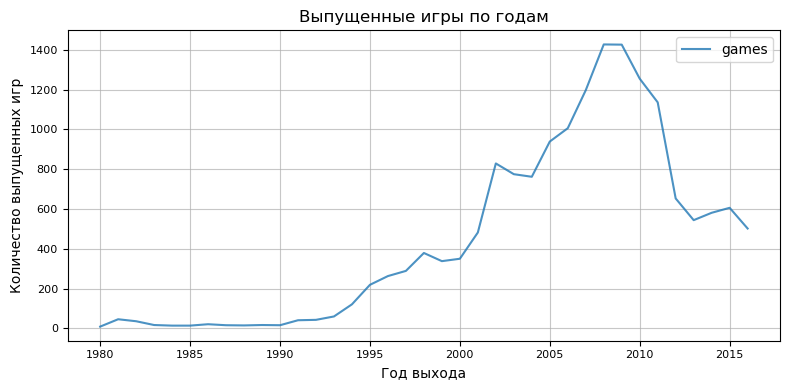

In [78]:
games_per_year.plot(figsize=(8, 4), alpha=.8)

plt.title('Выпущенные игры по годам', fontsize=12)
plt.xlabel('Год выхода', fontsize=10)
plt.ylabel('Количество выпущенных игр', fontsize=10)
plt.grid(alpha=.7)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

***Как мы видим на графике, меньше всего игр выпускалось до 1995 года, потом пошел подъем, и больше всего игр выпускалось в период с 2008 по 2009 года (1427 и 1426 штук соответственно).***

***В принципе, если бы мы анализировали выпуск игр в сравнении прошлой эпохи до 2000-х с современными тенденциями, то все данные были бы важны, также если бы у нас стояла задача построения моделей машинного обучения (тут важны все данные, даже если за некоторые года их совсем мало). Однако раз данных задач перед нами не стоит, и года с очень малым количеством данных могут исказить некоторые средние значения, предполагаю, что эти данные, до 1995 года мы будем опускать.***

### 3.2. Посмотрим, как менялись продажи по платформам. Выберем платформы с наибольшими суммарными продажами и построим распределение по годам.

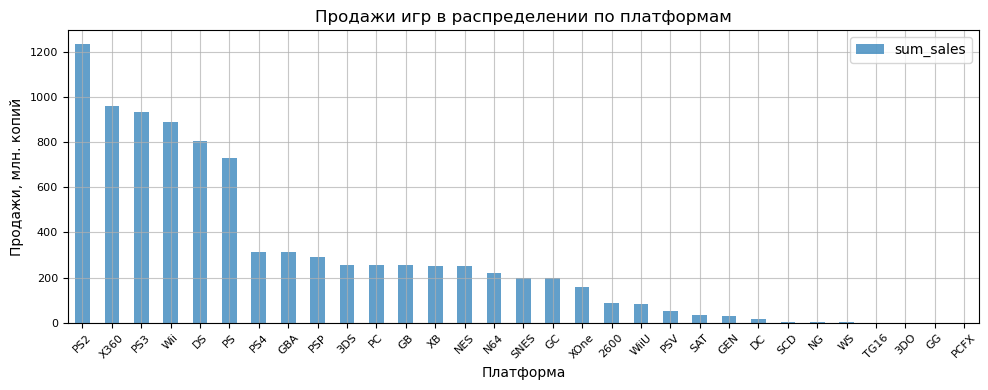

In [82]:
sales_per_platform = games.pivot_table(
    index='platform',
    values='sum_sales',
    aggfunc='sum'
).sort_values(by='sum_sales', ascending=False)

sales_per_platform.plot(kind='bar', figsize=(10, 4), alpha=.7)

plt.title('Продажи игр в распределении по платформам', fontsize=12)
plt.xlabel('Платформа', fontsize=10)
plt.ylabel('Продажи, млн. копий', fontsize=10)
plt.grid(alpha=.7)

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

***На графике очевидно выделяется шестерка лидеров по суммарным продажам - это платформы PS2, X360, PS3, Wii, DS и PS.***

Построим по ним распределение по годам, сделаем отдельный график по каждой платформе с помощью цикла:

In [86]:
sales_per_platform_top = sales_per_platform.head(6)
sales_per_platform_top

,sum_sales
platform,
PS2,1233.56
X360,961.24
PS3,931.34
Wii,891.18
DS,802.78
PS,727.58


Продажи игр платформе PS2 



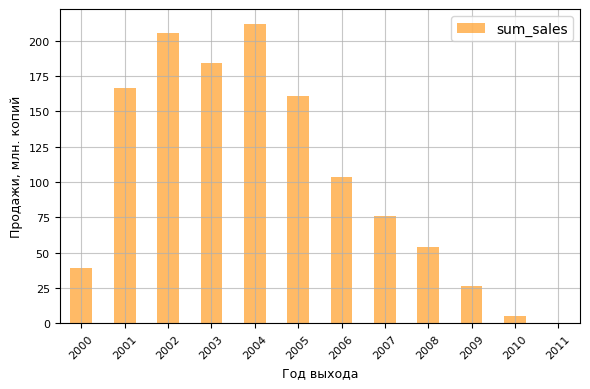

Продажи игр платформе X360 



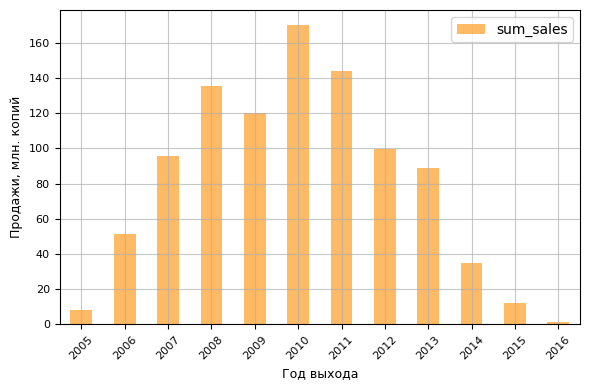

Продажи игр платформе PS3 



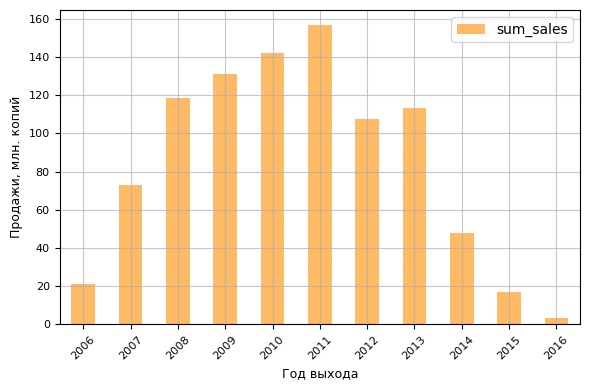

Продажи игр платформе Wii 



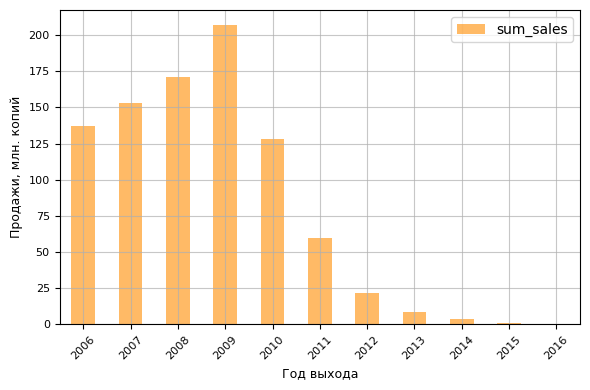

Продажи игр платформе DS 



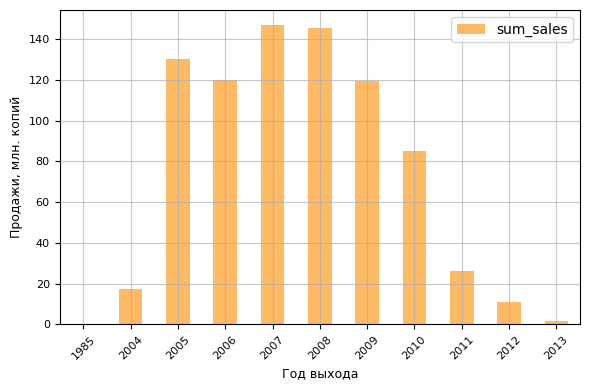

Продажи игр платформе PS 



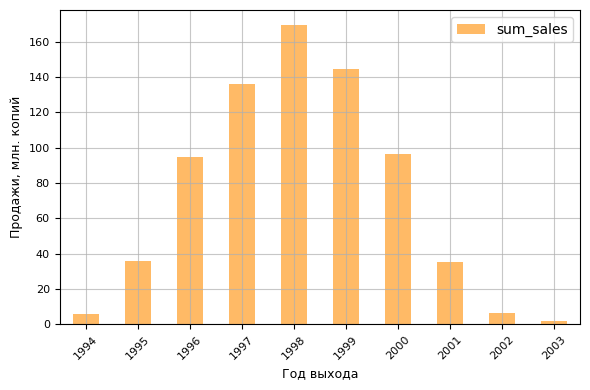

In [87]:
for platform in sales_per_platform_top.index[:6]:
    print('Продажи игр платформе', platform, '\n')
    games[games['platform'] == platform].pivot_table(index = ['year_of_release'], values = 'sum_sales', aggfunc = 'sum') \
    .plot(kind = 'bar', figsize=(6, 4), color='DarkOrange', alpha=.6)
    plt.xlabel('Год выхода', fontsize=9)
    plt.ylabel('Продажи, млн. копий', fontsize=9)
    plt.grid(alpha=.7)

    plt.xticks(rotation=45, fontsize=8)
    plt.yticks(fontsize=8)

    plt.tight_layout()
    plt.show()

***По построенным графикам посмотрим, в течение какого периоды платформы из шестерки лидеров были популярны:***

- PS2, платформа была популярна с 2001 года, популярность пошла на спад после 2005 года, возможно это связано с анонсами о дате выхода PS3, которая вышла в 2006 году
- X360, начала набирать популярность с 2007 года, а после 2013 года резко популярность пошла на спад
- PS3, вышла в конце 2006 года, но уже стабильно начала набирать популярность с 2008, после 2011 года популярность начала постепенно спадать, и после 2013 года продажи практически обрушились
- Wii, достаточно стабильно ворвалась на игровой рынок сразу в год выхода, 2006, затем до 2009 года набирала популярность, после пошел спад
- DS, в год выхода народ принял не особо тепло, но затем произошел резкий пик популярности с 2005 года и до 2010 года, после начался спад. **Здесь обратим внимание на графике на представленный 1985 год, изучим это внимательнее следующим шагом, возможно в данные закралась ошибка.**
- PS, график популярности продаж игр практически идеально похож на график нормального распределения, популярность начала расти значительно с 1996 года и после 2000 года начался спад, опять же скорее всего связано с выходом консоли PS2, именно в 2000 году.

За какой характерный срок появляются новые и исчезают старые платформы?

***Типичный цикл между поколениями консолей составляет 5-7 лет, новые платформы с выходом резко набирают популярность, дальше идет период активной поддержки и выхода актуальных игр - примерно 3-5 лет, в течение этого периода платформы удерживают популярность, затем продажи с появлением новых платформ начинают идти на спад.***

### 3.3. Возьмем данные за соответствующий актуальный период.

Актуальный период определим в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.

Как мы ранее выяснили, период активной поддержки консолей и выхода актуальных игр составляет примерно 3-5 лет, возьмем среднее значение, посмотрим данные за последние 4 года: 2013, 2014, 2015 и 2016 год.

In [95]:
actual_period = games.loc[games['year_of_release'] > 2012]
actual_period

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,0.0,-1.0,не указан,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,0.0,-1.0,не указан,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,-1.0,не указан,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,0.0,-1.0,не указан,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.0,-1.0,не указан,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,-1.0,не указан,0.01


In [96]:
actual_period.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     2233 non-null   float64
 9   user_score       2233 non-null   float64
 10  rating           2233 non-null   object 
 11  sum_sales        2233 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 226.8+ KB


***Мы сформировали датасет с данными за 2013 - 2016 гг, в дальйнешем исследовании данные за предыдущие года учитывать не будем.***

### 3.4. Выберем несколько потенциально прибыльных платформ. Какие платформы лидируют по продажам, растут или падают? 

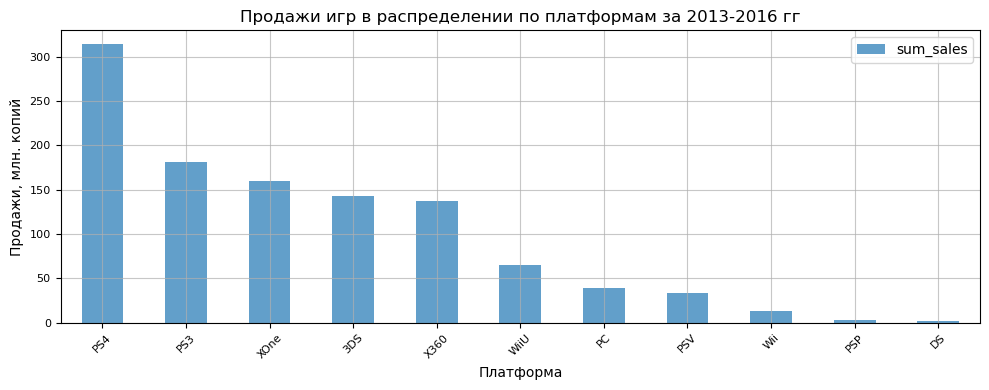

In [100]:
actual_period_sales = actual_period.pivot_table(
    index='platform',
    values='sum_sales',
    aggfunc='sum'
).sort_values(by='sum_sales', ascending=False)

actual_period_sales.plot(kind='bar', figsize=(10, 4), alpha=.7)

plt.title('Продажи игр в распределении по платформам за 2013-2016 гг', fontsize=12)
plt.xlabel('Платформа', fontsize=10)
plt.ylabel('Продажи, млн. копий', fontsize=10)
plt.grid(alpha=.7)

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

***Как мы видим, за последние 4 года на графике ситуация немного иная, чем когда мы рассматривали продажи платформ за весь период. Сейчас на первое место вырвалась консоль PS4, на почетном втором месте XboxOne.***

***Интересно обратить внимание, что несмотря на то, что вышли уже следующие модели консолей PS и Xbox, предыдущие все еще держат лидерские позиции по продажам, что говорит о том, что обе консоли очень удачные, они перевесили даже продажи игр на платформе PC.***

***Очевидно, что потенциально прибыльными (другими словами, предсказуемыми) платформами являются консоли PlayStation и Xbox. На самом деле, судя даже по игровым форумам и сообществам Steam и Discord, есть ощущение, что PC - также потенциально прибыльная платформа, потому что игроки на ПК были, есть и будут, можно бесконечно кастомизировать компьютеры. Даже у людей, далеких от игрового мира, практически всегда на слуху слова PlayStation, Xbox, ну и конечно же ПК.***

### 3.5. Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам.

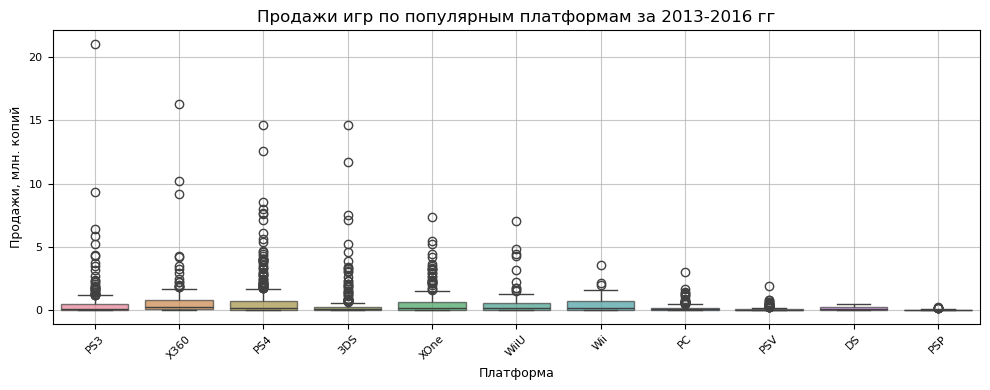

In [104]:
platform_order = (
    actual_period.groupby("platform")["sum_sales"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=actual_period,
    y='sum_sales',
    x='platform',
    boxprops={"alpha": .7},
    hue='platform')

plt.title('Продажи игр по популярным платформам за 2013-2016 гг', fontsize=12)
plt.xlabel('Платформа', fontsize=9)
plt.ylabel('Продажи, млн. копий', fontsize=9)
plt.grid(alpha=.7)

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

***По графику видим несколько очень больших значений, есть даже продажи более 14 млн. проданных копий у консоли PS4 - что является рекордным значением за весь исследуемый период. Избавляться от этих "выбросов" не будем, для более наглядного представления "ящика с усами" зададим просто диапазон по оси y.***

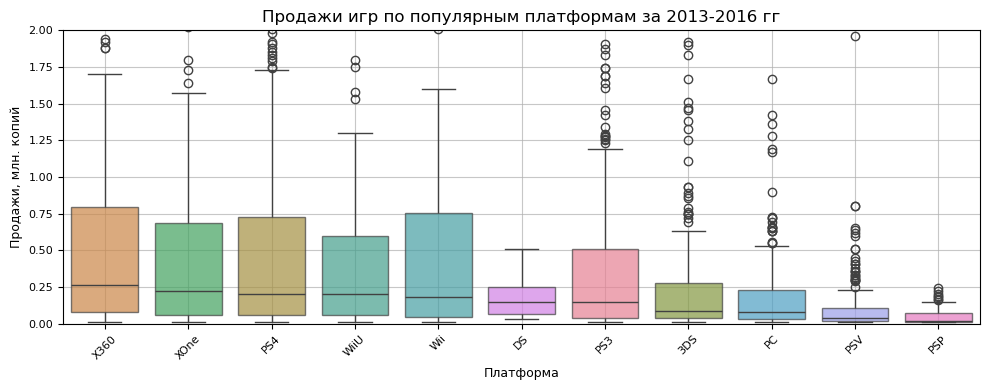

In [106]:
platform_order = (
    actual_period.groupby("platform")["sum_sales"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 4))
ax = sns.boxplot(
    data=actual_period,
    y='sum_sales',
    x='platform',
    boxprops={"alpha": .7},
    hue='platform',
    order = platform_order,
    dodge=False)

ax.set_ylim(0, 2)

plt.title('Продажи игр по популярным платформам за 2013-2016 гг', fontsize=12)
plt.xlabel('Платформа', fontsize=9)
plt.ylabel('Продажи, млн. копий', fontsize=9)
plt.grid(alpha=.7)

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

***В результате построенного графика, платформы PS, Xbox и Wii демонстрируют устойчивые показатели продаж, что подтверждается относительно короткими "усами" графиков, свидетельствующими о низком разбросе данных, а медианные значения находятся примерно на одном уровне, что указывает на стабильность спроса.***

***Остальные, менее перспективные платформы, характеризуются значительно большей вариативностью продаж, что видно на значительном количестве экстремальных выбросов и присутствии единичных успешных релизов (отдельные точки-выбросы на графике), не формирующих устойчивый тренд.***

### 3.6. Посмотрим, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков.

Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами и сформулируем выводы. 

***Выберем платформу PS4 - это самая топовая консоль, и большинство моих любимых игр было выпущено экслюзивом именно на данной платформе.***

Отфильтруем наши обработанные пропущенные значения, чтобы не было влияния на наш подсчет корреляции:

In [115]:
PS4_actual_period = actual_period.query('platform == "PS4" & user_score > -1 & critic_score > 0')
PS4_actual_period = PS4_actual_period.loc[:,['sum_sales', 'critic_score', 'user_score']]
display(PS4_actual_period.corr())

,sum_sales,critic_score,user_score
sum_sales,1.000000,0.405895,-0.033625
critic_score,0.405895,1.000000,0.557654
user_score,-0.033625,0.557654,1.000000


***Как мы видим из матрицы корреляции, между суммарными продажами и оценками критиков есть умеренная положительная взаимосвязь (0.405895, чем выше оценки критиков, тем больше продаж), получается, что покупатели периодически обращают внимание на оценки критиков при покупке игр.***

***Между суммарными продажами и оценками пользователей практически отсутствует связь (-0.033625, оценки пользователей не влияют на продажи).***

***Зависимость между оценками пользователей и критиков прослеживается положительная связь (0.557654, чем выше оценки критиков, тем выше оценки пользователей), что означает либо то, что мнения критиков и пользователей сходятся во мнениях (что сомнительно на мой взгляд), либо эффект авторитета, что высокие оценки критиков могут влиять на восприятие пользователей.***

Построим график корреляции итоговых продаж и пользовательских оценок:

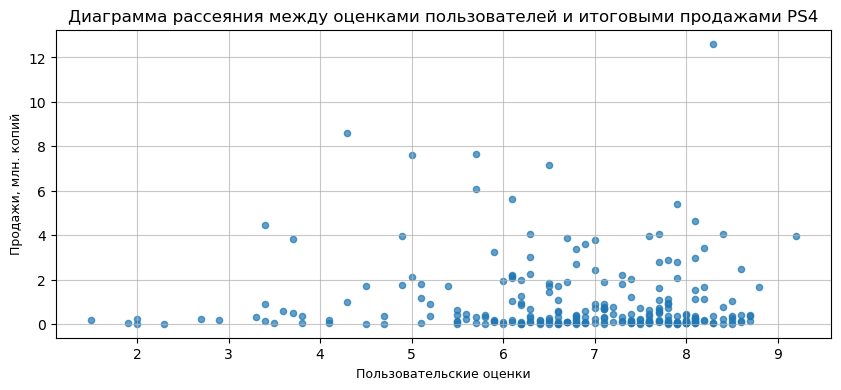

In [118]:
(
    actual_period.query('platform == "PS4" & user_score > -1 & critic_score > 0')
    .plot(x='user_score', 
          y='sum_sales', 
          kind='scatter', 
          figsize=(10, 4),
          alpha=.7)
)

plt.title('Диаграмма рассеяния между оценками пользователей и итоговыми продажами PS4', fontsize=12)
plt.xlabel('Пользовательские оценки', fontsize=9)
plt.ylabel('Продажи, млн. копий', fontsize=9)
plt.grid(alpha=.7)

plt.show()

***На графике мы увидели, что зависимости между пользовательскими оценками и итоговыми продажами игр на платформе PS4 не прослеживается.***

Построим график корреляции итоговых продаж и оценок критиков:

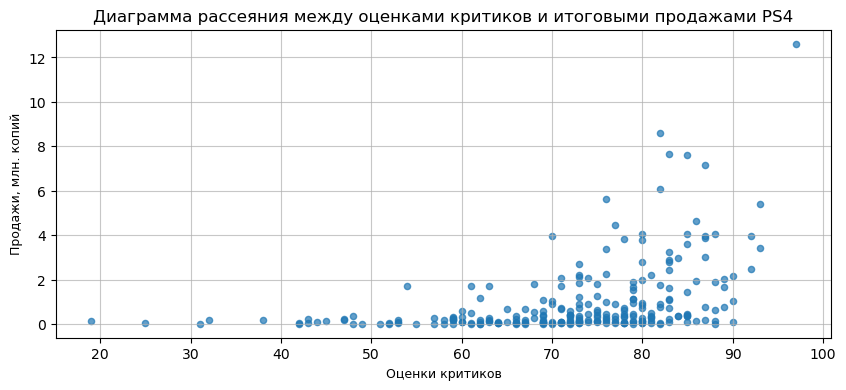

In [121]:
(
    actual_period.query('platform == "PS4" & user_score > -1 & critic_score > 0')
    .plot(x='critic_score', 
          y='sum_sales', 
          kind='scatter', 
          figsize=(10, 4),
          alpha=.7)
)

plt.title('Диаграмма рассеяния между оценками критиков и итоговыми продажами PS4', fontsize=12)
plt.xlabel('Оценки критиков', fontsize=9)
plt.ylabel('Продажи, млн. копий', fontsize=9)
plt.grid(alpha=.7)

plt.show()

***На графике мы увидели, что есть умеренная положительная зависимость между оценками критиков и итоговыми продажами игр на платформе PS4.***

### 3.7. Соотнесем выводы с продажами игр на других платформах.

Построим матрицы корреляций итоговых продаж с оценками пользователей и критиков и визуализируем с помощью heatmap на ранее выведенном топ-6 популярных платформ:

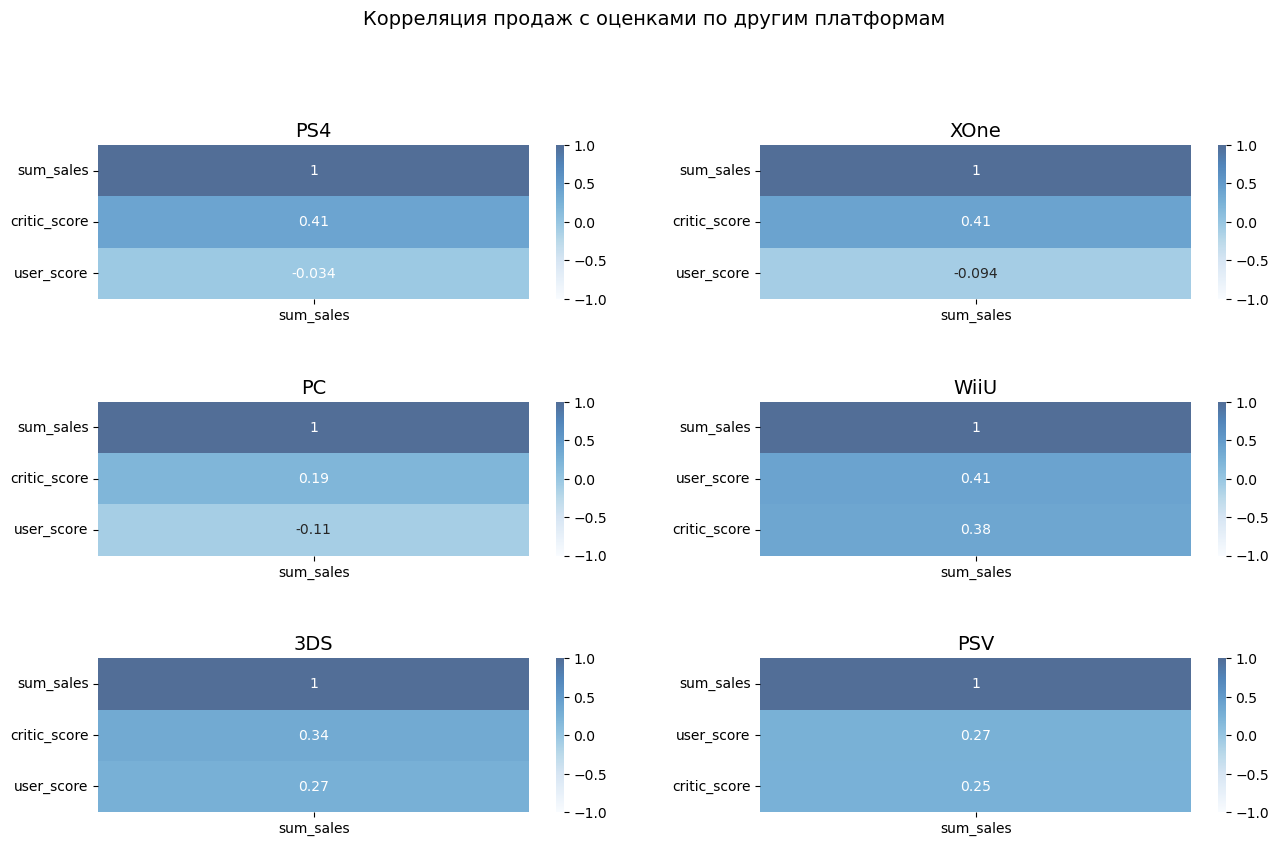

In [125]:
other_platforms = ['PS4','XOne','PC','WiiU','3DS', 'PSV']

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
fig.suptitle("Корреляция продаж с оценками по другим платформам", fontsize=14)

for platform, ax in zip(other_platforms, axes.flat):
    games_filtered = actual_period[(actual_period['platform'] == platform) & (actual_period['user_score'] > -1) & (actual_period['critic_score'] > 0)] \
    [['sum_sales', 'critic_score', 'user_score']]
    
    heatmap = sns.heatmap(
        games_filtered.corr()[['sum_sales']].sort_values('sum_sales', ascending=False),
        cmap='Blues',
        annot=True,
        annot_kws={'size': 10},
        cbar=True,
        ax=ax,
        vmin=-1,
        vmax=1,
        alpha=.7
    )
    ax.set_title(platform, fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
    # Настроим позицию colorbar
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)

plt.tight_layout(pad=4.0)
plt.show()

***У всех 6 платформ наблюдается умеренная корреляция между продажами и оценками критиков, а вот между итоговыми продажами и оценками пользователей либо связь отсутствует полностью, либо она практически нулевая. За исключением платформ WiiU и 3DS - здесь мы видим умеренную положительную корреляцию между продажами и пользовательскими оценками.***

### 3.8. Посмотрим на общее распределение игр по жанрам.

Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

In [130]:
actual_period.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,0.0,-1.0,не указан,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,0.0,-1.0,не указан,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


In [131]:
sales_per_genre = actual_period.groupby('genre').agg({'name':'count', 'sum_sales':'sum'}).sort_values(by='sum_sales', ascending=False)
sales_per_genre

,name,sum_sales
genre,,
Action,766,321.87
Shooter,187,232.98
Sports,214,150.65
Role-Playing,292,145.89
Misc,155,62.82
Platform,74,42.63
Racing,85,39.89
Fighting,80,35.31
Adventure,245,23.64


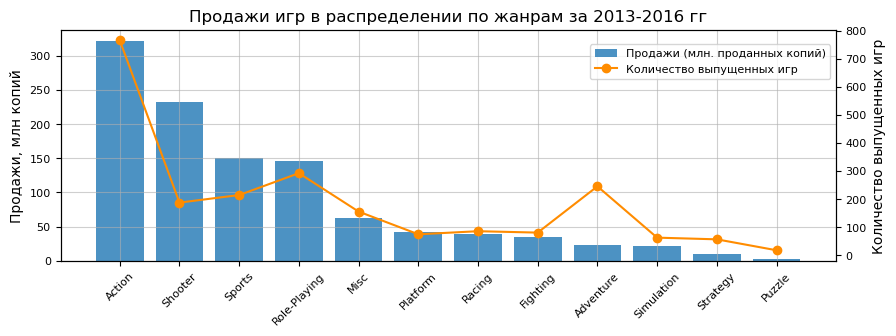

In [132]:
fig, ax1 = plt.subplots(figsize=(10, 3))

ax1.bar(sales_per_genre.index, sales_per_genre['sum_sales'], alpha=.8, label='Продажи (млн. проданных копий)')
ax1.set_ylabel('Продажи, млн копий')
ax1.tick_params(axis='y', labelsize=8)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.grid(alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(sales_per_genre.index, sales_per_genre['name'], marker='o', color='DarkOrange', label='Количество выпущенных игр')
ax2.set_ylabel('Количество выпущенных игр')
ax2.tick_params(axis='y', labelsize=8)

plt.title('Продажи игр в распределении по жанрам за 2013-2016 гг', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(fontsize=8)

fig.legend(fontsize=8, loc='upper right', bbox_to_anchor=(0.9, 0.85))

plt.show()

***Как мы видим, явно выделяются 3 самых прибыльных жанра - Action (абсолютный лидер (321.87 млн копий), несмотря на большое количество игр в жанре (766)), Shooter (второй по продажам (232.98 млн копий), при этом игр в этом жанре значительно меньше (187), что говорит о более высокой средней выручке на одну игру) и Sports (высокая популярность объясняется регулярными релизами).*** 

***Также стоит обратить внимание на жанр Adventure – несмотря на 245 игр, продажи 23.64 млн копий, что говорит о низкой средней выручке.***

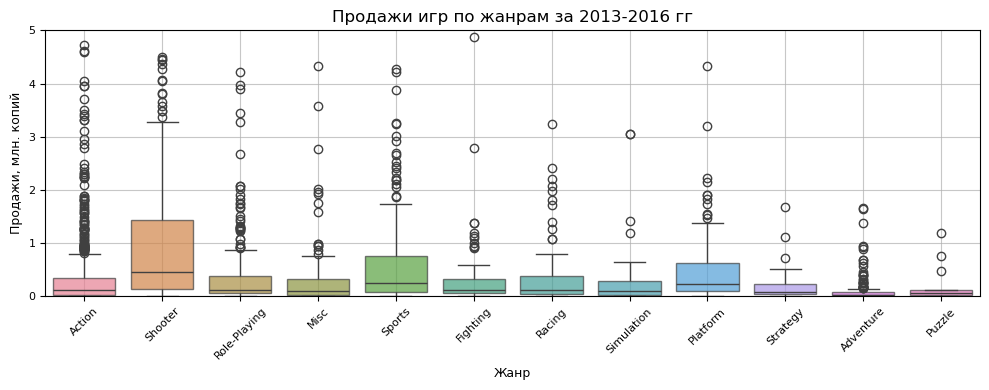

In [134]:
plt.figure(figsize=(10, 4))
ax = sns.boxplot(data = actual_period, y = 'sum_sales', x='genre', boxprops={"alpha": .7}, hue='genre', dodge=False)

ax.set_ylim(0, 5)

plt.title('Продажи игр по жанрам за 2013-2016 гг', fontsize=12)
plt.xlabel('Жанр', fontsize=9)
plt.ylabel('Продажи, млн. копий', fontsize=9)
plt.grid(alpha=.7)

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

***По медианным значениям Shooter – самый прибыльный жанр - высокая медиана (~1.5–2 млн копий на игру) и максимальные выбросы (отдельные игры продаются лучше среднего) и самый стабильный спрос у жанра Sports - узкий разброс данных, но высокие продажи у отдельных топовых игр. Также судя по медиане можно отметить жанр Platform, не самый прибыльный, но стабильный жанр, однако рассчитанный на узкую целевую аудиторию.***

***ВЫВОДЫ:***

**1. Корректировка данных**

- Период до 1995 года исключен из анализа в связи с малым количеством данных, что могло искажать средние показатели.

- *Фокус на актуальных данных:* 

Основной анализ проведен за 2013–2016 гг. (4 года), так как жизненный цикл консолей составляет 3–5 лет, соответственно подобный период отражает современные тренды игровой индустрии.

**2. ТОП-6 самых прибыльных платформ**

По суммарным продажам игр лидируют PS2 (PlayStation 2), X360 (Xbox 360), PS3 (PlayStation 3), Wii (Nintendo Wii), DS (Nintendo DS), PS (PlayStation 1)
PS4 показала рекордные продажи (14+ млн копий для отдельных игр), но не вошла в общий топ из-за ограниченного периода анализа (2013–2016).

**3. Перспективные платформы и жанры**

Прибыльные платформы: PlayStation (PS4, PS5) и Xbox (X360, XOne) – стабильно высокие продажи.
PC – на мой взгляд, вечно актуальная платформа благодаря кастомизации и цифровым дистрибуции (Steam, Epic Games).

Прибыльные жанры: Action, Shooter, Sports – лидеры по продажам и предсказуемости спроса.

**4. Корреляция между продажами и оценками**

Умеренная корреляция между продажами и оценками критиков (Metacritic, профессиональные обзоры). Практически нулевая связь между продажами и оценками пользователей. Видимо, пользовательские оценки часто субъективны и не влияют на коммерческий успех.

# Шаг 4. Составим портрет пользователя каждого региона

Определим для пользователя каждого региона (NA, EU, JP):

- Самые популярные платформы (топ-5). Опишите различия в долях продаж.
- Самые популярные жанры (топ-5). Поясните разницу.
- Влияет ли рейтинг ESRB на продажи в отдельном регионе?

Расшифруем, какие рейтинги представлены в нашем датасете:

- `E` **(Everyone)** - 6+ лет, подходит для всех возрастов (безопасный контент)
- `E10+` **(Everyone 10+)** - 10+ лет, может содержать легкую анимацию, комическое насилие или минимальный риск
- `T` **(Teen)** - 13+ лет, умеренное насилие, кровь, грубый юмор или темы для подростков
- `M` **(Mature)** - 17+ лет, жестокое насилие, кровь, сексуальные темы, крепкая лексика
- `AO` **(Adults Only)** - 18+ лет, откровенный сексуальный контент или экстремальное насилие (редко)
- `K-A` **(Kids to Adults)** - 6+ лет, устаревший рейтинг (использовался до 1998, аналогичен E)
- `EC` **(Early Childhood)** - 3+ лет, игры для маленьких детей (обучающие, без риска)
- `RP` **(Rating Pending)**	— рейтинг ещё не присвоен (например, для анонсированных игр)
- `не указан` — рейтинг отсутствует (например, для старых игр или неофициальных релизов)

Начнем с пользователей Северной Америки, исследуем топ-5 популярных платформ, топ-5 популярных жанров и влияние рейтинга ESRB на продажи в данном регионе:

In [142]:
na_platforms = actual_period.groupby('platform').agg({'na_sales': 'sum'}).sort_values(by='na_sales', ascending=False).reset_index().head()
na_genres = actual_period.groupby('genre').agg({'na_sales': 'sum'}).sort_values(by='na_sales', ascending=False).reset_index().head()
na_rating = actual_period.groupby('rating').agg({'na_sales': 'sum'}).sort_values(by='na_sales', ascending=False).reset_index().head()

Визуализируем портрет пользователя для региона Северная Америка с помощью круговых диаграмм:

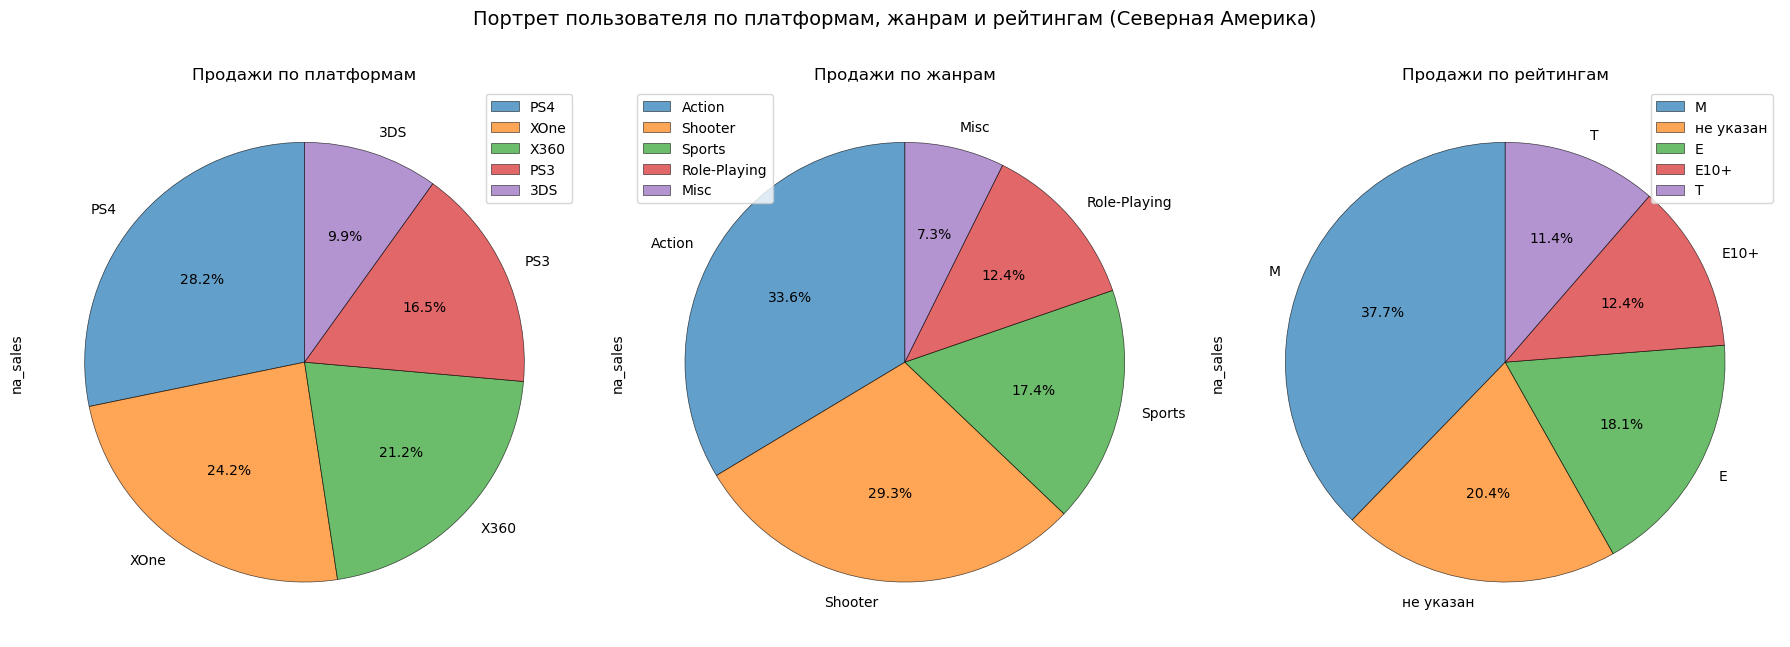

In [144]:
fig, ax = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Портрет пользователя по платформам, жанрам и рейтингам (Северная Америка)", fontsize=14)
wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}

na_platforms.plot.pie(y='na_sales', labels=na_platforms['platform'], autopct='%1.1f%%', ax=ax[0], wedgeprops=wedge_props, startangle=90)
ax[0].set_title('Продажи по платформам')

na_genres.plot.pie(y='na_sales', labels=na_genres['genre'], autopct='%1.1f%%', ax=ax[1], wedgeprops=wedge_props, startangle=90)
ax[1].set_title('Продажи по жанрам')

na_rating.plot.pie(y='na_sales', labels=na_rating['rating'], autopct='%1.1f%%', ax=ax[2], wedgeprops=wedge_props, startangle=90)
ax[2].set_title('Продажи по рейтингам')

plt.tight_layout()
plt.show()

***По региону Северная Америка игры на платформах PS4 и Xbox доминируют (что говорит о сильной позиции Sony и популярности Microsoft в данном регионе), Nintendo отстаёт. Это означает, что консольный рынок сильнее, чем портативный (3DS).***

***Самые прибыльные жанры - это экшены и шутеры, спорт и RPG — стабильные, но менее массовые.***

***Главный хит по региону Северная Америка - это игры для взрослых (M), также семейные игры (E/E10+) сохраняют значительную долю. Здесь также стоит отметить, что очень большая доля игр с неуказанным рейтингом (возможно большая доля по данному региону - это, например, инди-игры).***

Следующий регион для анализа продаж - Европа:

In [147]:
eu_platforms = actual_period.groupby('platform').agg({'eu_sales': 'sum'}).sort_values(by='eu_sales', ascending=False).reset_index().head()
eu_genres = actual_period.groupby('genre').agg({'eu_sales': 'sum'}).sort_values(by='eu_sales', ascending=False).reset_index().head()
eu_rating = actual_period.groupby('rating').agg({'eu_sales': 'sum'}).sort_values(by='eu_sales', ascending=False).reset_index().head()

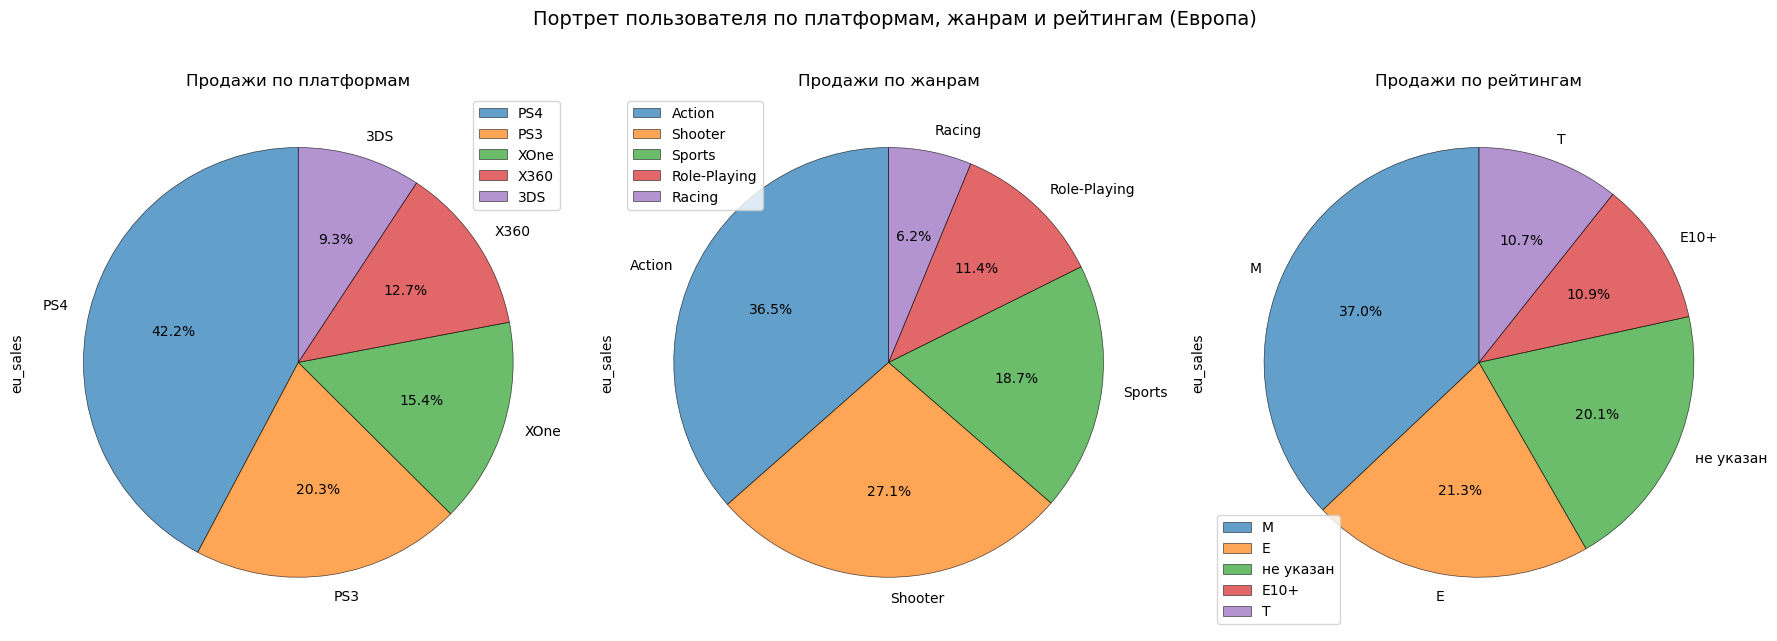

In [148]:
fig, ax = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Портрет пользователя по платформам, жанрам и рейтингам (Европа)", fontsize=14)
wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}

eu_platforms.plot.pie(y='eu_sales', labels=eu_platforms['platform'], autopct='%1.1f%%', ax=ax[0], wedgeprops=wedge_props, startangle=90)
ax[0].set_title('Продажи по платформам')

eu_genres.plot.pie(y='eu_sales', labels=eu_genres['genre'], autopct='%1.1f%%', ax=ax[1], wedgeprops=wedge_props, startangle=90)
ax[1].set_title('Продажи по жанрам')

eu_rating.plot.pie(y='eu_sales', labels=eu_rating['rating'], autopct='%1.1f%%', ax=ax[2], wedgeprops=wedge_props, startangle=90)
ax[2].set_title('Продажи по рейтингам')

plt.tight_layout()
plt.show()

***В Европе PlayStation значительно сильнее, чем в предыдущем регионе, Xbox наоборот менее популярен в Европе, Nintendo отстаёт в обеих регионах. В Европе также консольный рынок сильнее, чем портативный (3DS).***

***Экшены и шутеры лидируют в обоих регионах, но в предыдущем, Северной Америке, они ещё популярнее. Спорт (FIFA, NBA, F1) силён в Европе, но в Северной Америке его доля чуть выше.***

***M-игры (например, GTA, Call of Duty) лидируют и там, и там, но в Северной Америке их доля выше. Здесь же, в Европе семейные игры (E) популярнее. В данном регионе также очень большая доля проданных игр - это игры без указания рейтинга, что может быть упущенной возможностью, например, для маркетинговых активностей - стоило бы изучить эти игры подробнее.***

Посмотрим, как обстоит дело в Японии:

In [151]:
jp_platforms = actual_period.groupby('platform').agg({'jp_sales': 'sum'}).sort_values(by='jp_sales', ascending=False).reset_index().head()
jp_genres = actual_period.groupby('genre').agg({'jp_sales': 'sum'}).sort_values(by='jp_sales', ascending=False).reset_index().head()
jp_rating = actual_period.groupby('rating').agg({'jp_sales': 'sum'}).sort_values(by='jp_sales', ascending=False).reset_index().head()

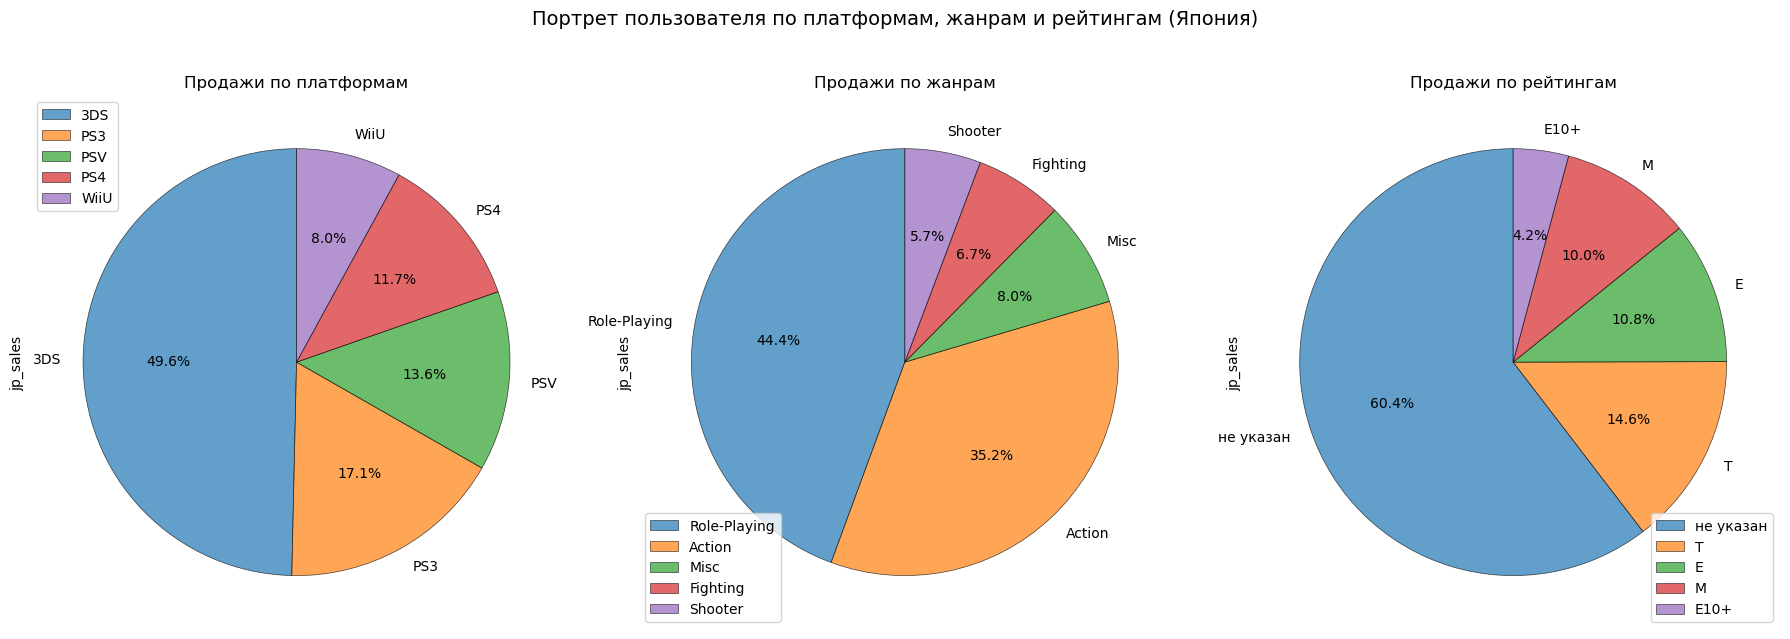

In [152]:
fig, ax = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Портрет пользователя по платформам, жанрам и рейтингам (Япония)", fontsize=14)
wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}

jp_platforms.plot.pie(y='jp_sales', labels=jp_platforms['platform'], autopct='%1.1f%%', ax=ax[0], wedgeprops=wedge_props, startangle=90)
ax[0].set_title('Продажи по платформам')

jp_genres.plot.pie(y='jp_sales', labels=jp_genres['genre'], autopct='%1.1f%%', ax=ax[1], wedgeprops=wedge_props, startangle=90)
ax[1].set_title('Продажи по жанрам')

jp_rating.plot.pie(y='jp_sales', labels=jp_rating['rating'], autopct='%1.1f%%', ax=ax[2], wedgeprops=wedge_props, startangle=90)
ax[2].set_title('Продажи по рейтингам')

plt.tight_layout()
plt.show()

***Япония радикально отличается от западных рынков (Северной Америки и Европы) по платформам, жанрам и рейтингам.***

***Nintendo 3DS — абсолютный лидер, что подтверждает любовь японцев к портативным консолям. PS4 менее востребована из-за меньшего интереса к западным блокбастерам (например, Call of Duty, FIFA).***

***RPG — король жанров. Японцы любят глубокие сюжеты (RPG) и также довольно популярны экшены.***

***Большинство игр не имеют рейтинга (60,4% !), вероятно это можно объяснить тем, что в Японии рейтинги ESRB не всегда указываются (используется местная система рейтингов). Подростковые (T) и детские (E) игры популярнее "взрослых" (M) - аудитория предпочитает семейные и подростковые игры, а не хардкорные M-проекты.***

***ВЫВОДЫ:***

Были проанализированы продажи компьютерных игр в трех разных регионах, мы выяснили, что это практически три разных игровых мира, в особенности Япония, выявили три портрета пользователей.

**🎮Портрет американского геймера NA:**

- играет на: PlayStation 4 или Xbox One, консольный гейминг гораздо сильнее чем портативный.
- любимые жанры: экшены (GTA) и шутеры (Call of Duty), а также спортивные симуляторы.
- предпочитает игры рейтинга M — "взрослые" игры с насилием, драмами и сложными сюжетами.

---

**🎮Портрет европейского геймера EU:**

- играет на: PlayStation 4, меньше интереса к Xbox, чем в Северной Америке.
- любимые жанры: экшены (Assassin’s Creed), шутеры (Battlefield), спортивные жанры (F1).
- предпочитает также игры рейтинга M, но семейные игры (E) тоже популярны.

---

**🎮Портрет японского геймера JP:**

- играет на: Nintendo 3DS, портативные игры значительно популярнее, чем домашние консоли.
- любимые жанры: ролевые игры и экшены. Также важно помнить, что в Японии очень популярна аниме-стилистика.
- предпочитает игры рейтинга T (13+), "взрослые" (M) игры почти не популярны. Также для львиной доли игр рейтинги не указаны.

При планировании продаж игр в разных регионах, возможно стоит ориентироваться на рейтинг ESRB в западных регионах - в Европе и Северной Америке, однако совсем не стоит ориентироваться в Японии (очень большая доля игр без указания рейтинга, либо своя рейтинговая система).

# Шаг 5. Проверим гипотезы

### 5.1. Гипотеза 1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Зададим пороговое значение alpha = 0,05.

Для проверки гипотезы применим двухвыборочный t-тест Стьюдента о равенстве средних двух генеральных совокупностей.

**H₀ (нулевая гипотеза)**: средние пользовательские рейтинги платформ Xbox One и PC равны.

**H₁ (альтернативная гипотеза)**: средние пользовательские рейтинги платформ Xbox One и PC не равны.

In [159]:
print(
    'Средний пользовательский рейтинг платформы Xbox One',
    round(actual_period.query('platform == "XOne" and user_score > -1')['user_score'].mean(), 2)
)
print(
    'Средний пользовательский рейтинг платформы PC',
    round(actual_period.query('platform == "PC" and user_score > -1')['user_score'].mean(), 2)
)

Средний пользовательский рейтинг платформы Xbox One 6.52
Средний пользовательский рейтинг платформы PC 6.27


In [160]:
results = st.ttest_ind(
    actual_period.query('platform == "XOne" and user_score > -1')['user_score'], 
    actual_period.query('platform == "PC" and user_score > -1')['user_score'], 
    equal_var=False)

alpha = 0.05

print(f'p-значение: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-значение: 0.14759594013430463
Нет оснований отвергнуть нулевую гипотезу


***Нет оснований отвергнуть нулевую гипотезу о равенстве средних пользовательскиз рейтингов платформ Xbox One и PC, т.е. нет оснований полагать, что рейтинги двух популярных платформ значимо различаются. Значит пользователи ставят примерно одинаковые оценки играм на той и другой платформах.***

***Интересно, если бы мы сравнивали рейтинги игр данных платформ с рейтингами игр на платформе PS, вероятно, результат был бы иным, но это только предположения, в рамках данного исследования эту гипотезу мы не проверяем.***

### 5.2. Гипотеза 2. Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

**H₀ (нулевая гипотеза)**: средние пользовательские рейтинги жанров Action и Sports равны.

**H₁ (альтернативная гипотеза)**: средние пользовательские рейтинги жанров Action и Sports не равны.

In [164]:
actual_period.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sum_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,0.0,-1.0,не указан,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,0.0,-1.0,не указан,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


In [165]:
print(
    'Средний пользовательский рейтинг жанра Action',
    round(actual_period.query('genre == "Action" and user_score > -1')['user_score'].mean(), 2)
)
print(
    'Средний пользовательский рейтинг жанра Sports',
    round(actual_period.query('genre == "Sports" and user_score > -1')['user_score'].mean(), 2)
)

Средний пользовательский рейтинг жанра Action 6.84
Средний пользовательский рейтинг жанра Sports 5.24


In [166]:
results = st.ttest_ind(
    actual_period.query('genre == "Action" and user_score > -1')['user_score'], 
    actual_period.query('genre == "Sports" and user_score > -1')['user_score'], 
    equal_var=False)

alpha = 0.05

print(f'p-значение: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-значение: 1.4460039700704315e-20
Отвергаем нулевую гипотезу


***Нулевая гипотеза о равенстве средних пользовательских рейтингов двух жанров не подтвердилась, отвергаем нулевую гипотезу. Значит пользователи ставят разные оценки играм в жанре Action и играм в жанре Sports.***

***ВЫВОДЫ:***

1. Мы не смогли отвергнуть нулевую гипотезу о равенстве средних пользовательскиз рейтингов двух платформ Xbox One и PC, т.е. пользователи ставят примерно одинаковые оценки играм на той и другой платформах.
2. Нулевая гипотеза о равенстве средних пользовательских рейтингов двух жанров не подтвердилась, т.е. пользователи ставят разные оценки играм в жанре Action и играм в жанре Sports.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Верная проверка шипльех!

# Шаг 6. Общие выводы

**1. Подготовка и предобработка данных**

- Проведена комплексная очистка данных с устранением пропусков (особое внимание уделено столбцам с оценками, где пропуски превышали 50%)
- Оптимизированы типы данных для повышения эффективности анализа
- Создан агрегированный показатель суммарных продаж (sum_sales) для комплексной оценки успешности игр

**2. Анализ рыночных тенденций**

- Период до 1995 года исключен из анализа в связи с малым количеством данных, что могло искажать средние показатели.
- Основной анализ проведен за 2013–2016 гг. (4 года), так как жизненный цикл консолей составляет 3–5 лет, соответственно подобный период отражает современные тренды игровой индустрии.
- Выявлены лидирующие платформы: PlayStation и Xbox для западных рынков, Nintendo для Японии
- Определены наиболее прибыльные жанры: Action и Shooter (глобально), JRPG (для Японии)
- Установлена умеренная корреляция между коммерческим успехом и оценками критиков, при этом практически нулевая связь между продажами и оценками пользователей. Видимо, пользовательские оценки часто субъективны и не влияют на коммерческий успех.

**3. Потрет пользователя каждого региона**

🎮Портрет американского геймера NA:

играет на: PlayStation 4 или Xbox One, консольный гейминг гораздо сильнее чем портативный.
любимые жанры: экшены (GTA) и шутеры (Call of Duty), а также спортивные симуляторы.
предпочитает игры рейтинга M — "взрослые" игры с насилием, драмами и сложными сюжетами.

🎮Портрет европейского геймера EU:

играет на: PlayStation 4, меньше интереса к Xbox, чем в Северной Америке.
любимые жанры: экшены (Assassin’s Creed), шутеры (Battlefield), спортивные жанры (F1).
предпочитает также игры рейтинга M, но семейные игры (E) тоже популярны.

🎮Портрет японского геймера JP:

играет на: Nintendo 3DS, портативные игры значительно популярнее, чем домашние консоли.
любимые жанры: ролевые игры и экшены. Также важно помнить, что в Японии очень популярна аниме-стилистика.
предпочитает игры рейтинга T (13+), "взрослые" (M) игры почти не популярны. Также для львиной доли игр рейтинги не указаны.

**4. Региональные особенности**

- Северная Америка: доминирование консольного гейминга с акцентом на "взрослый" контент (рейтинг M)
- Европа: схожие с NA предпочтения, но с большим интересом к спортивным симуляторам
- Япония: уникальный рынок с преобладанием портативных консолей и аниме-стилистики

**5. Проверка гипотез**

- Пользовательские оценки не различаются для игр на Xbox One и PC
- Существуют значимые различия в оценках между жанрами Action и Sports

***Рекомендации***

**1. Ориентация на региональность**

- NA/EU: делать ставку на консольные экшены/шутеры с рейтингом M
- Япония: разрабатывать JRPG и файтинги для Nintendo Switch с аниме-стилистикой для портативных платформ. Япония остается очень нишевым рынком с уникальными предпочтениями.

**2. Прибыльные платформы**

- Рассматривать PlayStation и Xbox как наиболее стабильные платформы для западных рынков.
- Учитывать потенциал Nintendo Switch для азиатского региона

**3. На основе проведенных гипотез**

На основании проверенных гипотез нет необходимости адаптировать контент под конкретную платформу на основе пользовательских оценок, а также можно использовать единые рекламные кампании для обеих платформ (на основании схожих пользовательских оценок).

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Итоговый вывод полностью отражает проделанную работу

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту ревьювера v1**:

Елена, спасибо за  проект! Ты приложила много усилий, чтобы довести его до конца, проделана огромная работа, и это видно невооруженным глазом, ты большой молодец!

**Отмечу положительные моменты**:

1. Все разложено по полочкам, всегда понятен ход твоих мыслей, приятно смотреть

2. Отличные визуализации

3. На разных шагах проекта ты предлагала очень интересные решения и методы для их реализации. Хорошая работа!

**На что стоит обратить внимание**:

1. На желтые комменты, так как критических ошибок нет

**Удачи и жду твой проект на повторное ревью!**

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту ревьювера v2**:

Елена,  ошибки исправлены, проект принят, поздравляю тебя!